In [1]:
import numpy as np
import matplotlib.pyplot as plt
from qutip import *
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset
from scipy.integrate import odeint

import os
import time


In [2]:

def Kerr_system(N, Delta, K, Epsilon):
    a = destroy(N) 
    """
Esta función toma:
        Escalares
            N: Dim Hilbert
            Delta: Detuning
            K: Kerr NL
            Epsilon: Squeezing
        
    Regresa 
        Hamiltoniano: del sistema para un oscilador de Kerr 

     Hamiltoniano Kerr Oscillator de acuerdo al paper de Zhang2021:
         Detuning         (omega_d)
         No linealidad de Keer  (U)
         Squeezing              (G)
    """

    H = (
        - Delta*a.dag()*a               
        +  0.5*K* a.dag()*a.dag() *a*a       
        + 0.25*Epsilon* (a.dag()*a.dag() + a*a) 
        )
    
    return H
    
def Kerr_Diag(N, Delta, K, Epsilon, Jump_ops):
 
    '''
    Esta función toma:
        Escalares
            N: Dim Hilbert
            Delta: Detuning
            K: Kerr NL
            Epsilon: Squeezing
        Jump_ops: np.array[] de los operadores de salto
        
    Regresa
        Eigenvalores del sistema.
    '''
    
    H = Kerr_system(N, Delta, K, Epsilon)
    L = liouvillian(H, Jump_ops)
    eigs = L.eigenenergies()

    return eigs

def Kerr_evo(N, Delta, K, Epsilon, t, init_rho, Jump_ops, Expected_ops):
    '''
    Esta función toma:
        Escalares
            N: Dim Hilbert
            Delta: Detuning
            K: Kerr NL
            Epsilon: Squeezing
        t: array tipo linspace() de los valores del tiempo
        init_rho: Matriz de densidad inicial
        Jump_ops: array de los operadores de salto
        Expected_ops: array de los operadores que buscamos obtener su valor esperado
    
    Regresa 
        Estados evolucionados para cada paso de tiempo
        Evolución del valor de expectacion de los Expect_ops
    '''
    
    H = Kerr_system(N, Delta, K, Epsilon)


    evo = mesolve(H, init_rho, t, Jump_ops, e_ops = Expect_ops)

    return evo 

    



In [3]:
# -----------------------Parametros-------------------------------
N = [20,40,60,80,100]              # dim Hilbert space
# Loss 
g1 = 1
g2 = 0.5
K_list = np.array(
    [1/15, 1/30, 1/60, 1/75]     # Interaction, Kerr NL
    )             
Delta = 0                         # Detuning 
epsi_list = np.linspace(-2,2,200)    # Squeezing


# ------------------------------ CACHE ------------------------------
cache_folder = '1_2photon'
os.makedirs(cache_folder, exist_ok=True)
cache_file = os.path.join(cache_folder, 'NvsEpsi_data.npz')
# ------------------------------------------------------------------------------------------
if os.path.exists(cache_file):
    print("Cargando resultados desde caché...")
    data = np.load(cache_file, allow_pickle=True)
    # Acceso directo a los arrays
    n_ss_array = data['n_ss']  # Shape: (len(N), len(K_list), len(epsi_list))
    N_saved = data['N']
    K_saved = data['K_list']
    epsi_saved = data['epsi_list']
    print("----- O.o -----")

else:
    print("Calculando (esto puede tomar un momento)...") #------------------------------
    start_time = time.time()
    

    n_ss_all = np.zeros((len(N), len(K_list), len(epsi_list)))
    
    for i, d in enumerate(N):
        a = destroy(d)
        n = a.dag() * a
        salto = [
            np.sqrt(g1) * a,
            np.sqrt(g2) * a * a
        ]
        
        for j, K in enumerate(K_list):
            print(f"d={d}, K={K:.4f}" + '\n')
            
            for k, e in enumerate(epsi_list):
                H = Kerr_system(d, Delta, K, e)
                rho_ss = steadystate(H, salto)    
                n_ss = expect(n, rho_ss)
                
                n_ss_all[i, j, k] = n_ss
                
                if k < 5:
                    print(
                        rf"eps={e:.3f}, "
                        f"<n>={n_ss:.4f}, "
                        f"Tr={rho_ss.tr():.8f}, "
                        f"Tr^2={(rho_ss*rho_ss).tr():.8f}, "
                        f"minEig={np.min(rho_ss.eigenenergies()):.3e}"
                    )
            print('\n')
    
    elapsed_time = time.time() - start_time
    print(f"Tiempo de cálculo: {elapsed_time:.2f} segundos")
    
    # Guardar en formato npz comprimido
    np.savez_compressed(
        cache_file,
        n_ss=n_ss_all,
        N=np.array(N),
        K_list=K_list,
        epsi_list=epsi_list,
        g1=g1,
        g2=g2,
        Delta=Delta
    )
    print(f"Datos guardados en {cache_file}")




Cargando resultados desde caché...
----- O.o -----


C:\Users\Arturo\AppData\Local\Temp\ipykernel_28144\2089188372.py:8: RuntimeWarning: invalid value encountered in sqrt
  n_mfx =  (k*Delta + 0.5*g1*g2) + 0.5 * np.sqrt(r)


4


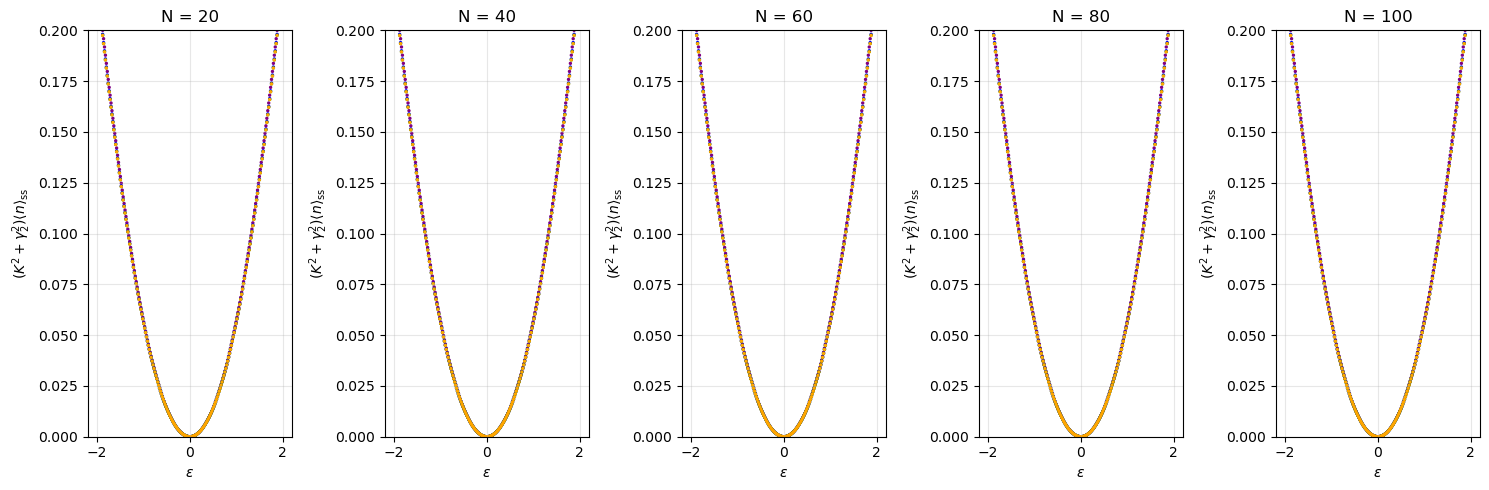

<Figure size 640x480 with 0 Axes>

In [5]:
#---------- Mean Field --------------------------------------
n_mf = []
for k in K_list:
    mf = []
    for e in epsi_list:
        
        r = e**2 *(k**2 + g2**2) - np.power(k*g1 - 2*g2*Delta, 2)
        n_mfx =  (k*Delta + 0.5*g1*g2) + 0.5 * np.sqrt(r)
        mf.append(n_mfx) 
    n_mf.append(np.array(mf))  
print(len(n_mf))
#------------------------------------------------------------
"""
Para la grafica en el eje x seria mi epsi_list y el eje y es K*n_1values
"""
fig, axes = plt.subplots(1, len(N), figsize=(15, 5))
colors = ['purple', 'blue', 'green', 'orange']

for idx_d, (ax, d) in enumerate(zip(axes, N)):
    for i, K in enumerate(K_list):
        ax.scatter(epsi_list,  (K**2 + g2**2) *n_ss_array[idx_d, i, :], 
                  c=colors[i % len(colors)], s=2, 
                  label=f"K={K:.4f}", ls= '-.'
                  )
        ax.plot(epsi_list, n_mf[i], 
                c=colors[i % len(colors)], lw=1, 
                linestyle='--', label='MF', alpha=0.5
               )
    ax.set_ylim(0,0.2)    
    ax.set_xlabel(r"$\epsilon$")
    ax.set_ylabel(r"$(K^2 + \gamma^2_2)\langle n\rangle_{\rm ss}$")
    ax.set_title(f"N = {d}")
#    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
plt.savefig('1_2photon/n_vs_epsilon.pdf')


# Eigenvalores

Cargando resultados desde caché...


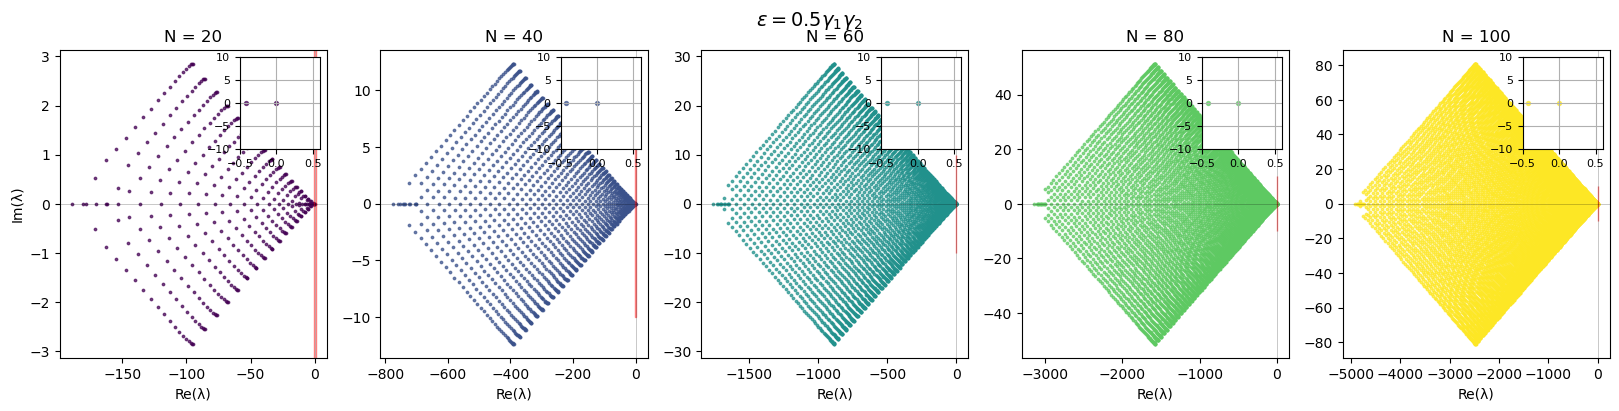

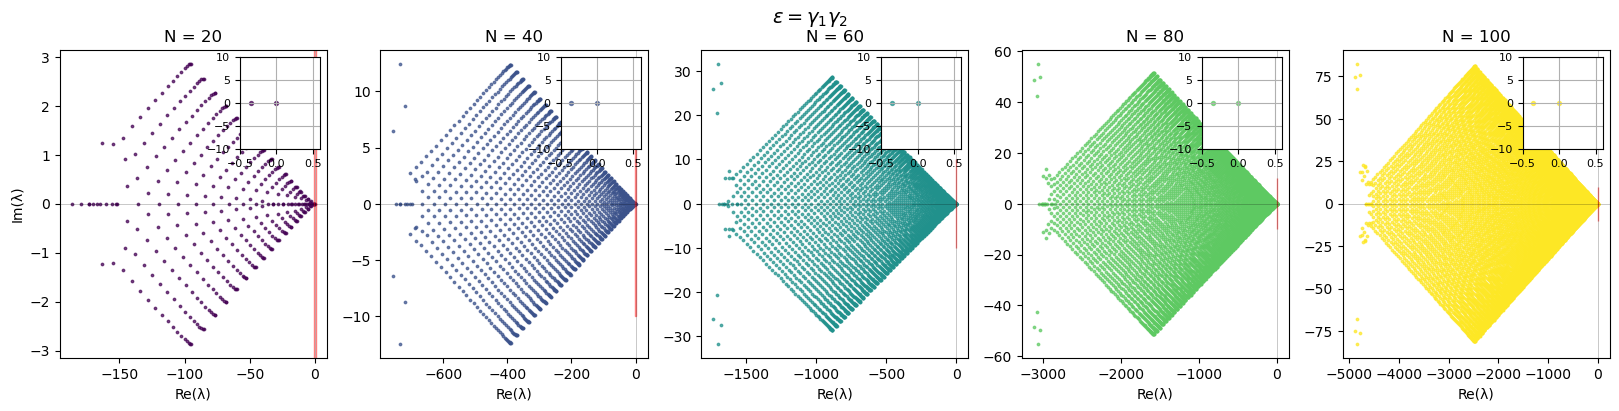

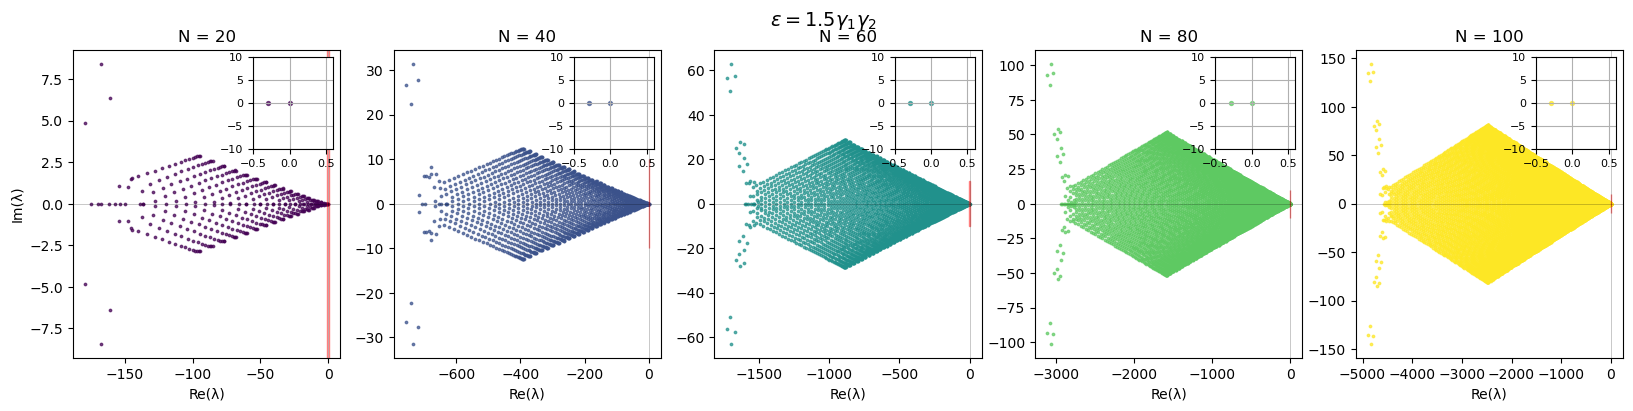

In [8]:
# Parámetros
N_values = [20, 40, 60, 80, 100]
g1, g2 = 1.0, 0.5
k = 1/60
Delta = 0
epsilon_values = [0.5*g1*g2, g1*g2, 1.5*g1*g2]
epsilon_labels = [r'$\epsilon = 0.5\gamma_1\gamma_2$', r'$\epsilon = \gamma_1\gamma_2$', r'$\epsilon = 1.5\gamma_1\gamma_2$']

# Archivo de caché ------------------------------------------------------------------------------------------------------------------------------------------------

cache_folder = '1_2photon'  # Carpeta
# Archivo de caché con extensión .qu
cache_file = os.path.join(cache_folder, f'eigenvalues_K{k}_g1g2{g1,g2}_cache.qu')

# Intentar cargar desde caché
if os.path.exists(cache_file):
    print("Cargando resultados desde caché...")
    results_cache = qload(f'1_2photon/eigenvalues_K{k}_g1g2{g1,g2}_cache')  
else:
    results_cache = {}
    print("Calculando eigenvalores (esto puede tomar un momento)...")
    start_time = time.time()
    
    for eps in epsilon_values:
        for N in N_values:
            key = f"N{N}_eps{eps}"
            salto = [
                np.sqrt(g1) * destroy(N),
                np.sqrt(g2) * destroy(N)* destroy(N)
                    ]
            eigs = Kerr_Diag(N, Delta, k, eps, salto)
            results_cache[key] = eigs
            print(f"  N={N}, eps={eps:.1f}g - listo")
    
    elapsed_time = time.time() - start_time
    print(f"Tiempo de cálculo: {elapsed_time:.2f} segundos")
    
    # Guardar en caché
    qsave(results_cache, f'1_2photon/eigenvalues_K{k}_g1g2{g1,g2}_cache')

#------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

# Crear figura - Una figura por cada valor de epsilon
for idx, (eps, label) in enumerate(zip(epsilon_values, epsilon_labels)):
    # Crear una figura con 5 subplots (una por cada N)
    fig, axes = plt.subplots(1, len(N_values), figsize=(20, 4))
    fig.suptitle(label, fontsize=14)
    
    colors = plt.cm.viridis(np.linspace(0, 1, len(N_values)))
    
    for i, N in enumerate(N_values):
        ax = axes[i]
        
        # Obtener eigenvalores del caché
        key = f"N{N}_eps{eps}"
        eigs = results_cache[key]
        
        X = np.real(eigs)
        Y = np.imag(eigs)
        
        ax.scatter(X, Y, s=3, c=[colors[i]], alpha=0.7, rasterized=True)
        
        ax.set_title(f'N = {N}', fontsize=12)
        ax.set_xlabel('Re(λ)', fontsize=10)
        if i == 0:
            ax.set_ylabel('Im(λ)', fontsize=10)
        
        ax.axhline(0, color='black', lw=0.5, alpha=0.3)
        ax.axvline(0, color='black', lw=0.5, alpha=0.3)
        
        # Opcional: ajustar límites si es necesario
        # ax.set_xlim([-20, 5])
        # ax.set_ylim([-50, 50])
        
        # Agregar zoom si quieres mantenerlo
        axins = inset_axes(ax, width="30%", height="30%", loc='upper right')
        mask = (X > -1.5) & (X < 1.5) & (Y > -15) & (Y < 15)
        if np.any(mask):
            axins.scatter(X[mask], Y[mask], s=8, c=[colors[i]], alpha=0.7)
        
        axins.set_xlim(-0.5, 0.6)
        axins.set_ylim(-10, 10)
        axins.grid(0.5)
        axins.tick_params(axis='both', labelsize=8)
        
        #axins.set_xticks([-2, -1.5, -1, -0.5, 0])
        axins.set_yticks([-10, -5, 0, 5, 10])
        
        # Indicador de zona de zoom
        from matplotlib.patches import Rectangle
        rect = Rectangle((-0.6, -10), 1.2, 20, 
                         linewidth=1, edgecolor='red', facecolor='none', alpha=0.5)
        ax.add_patch(rect)
    

    plt.savefig(f'1_2photon/eigsKerr_epsilon_{idx+1}.pdf', dpi=300)
    plt.show()

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


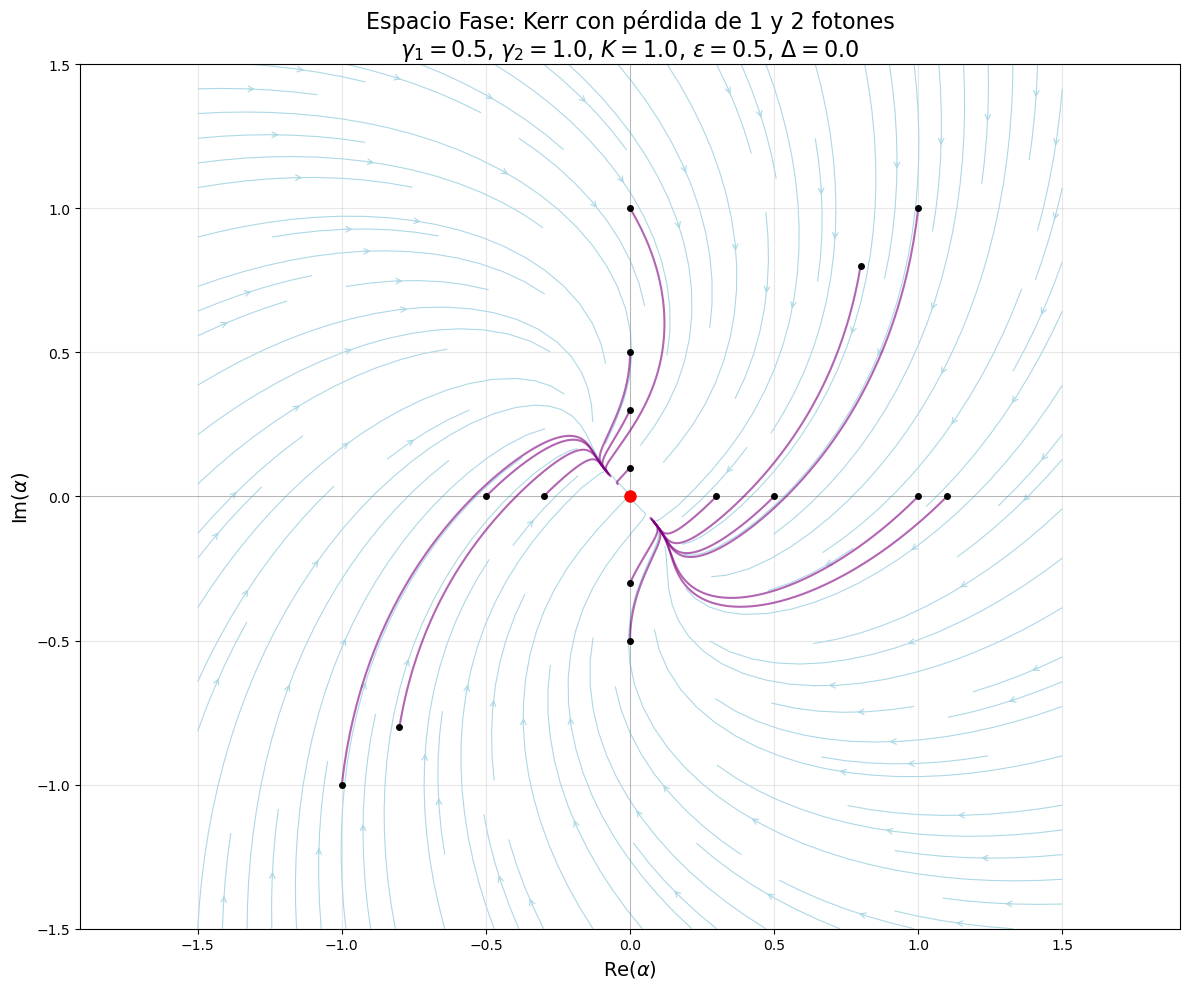

PUNTOS FIJOS - SISTEMA KERR CON PÉRDIDA DE 1 Y 2 FOTONES
γ₁ = 0.5 (pérdida 1 fotón)
γ₂ = 1.0 (pérdida 2 fotones)
K = 1.0, ε = 0.5, Δ = 0.0

Trivial:
  α = 0.000000+0.000000j
  |α| = 0.000000
  n = |α|² = 0.000000
  θ = 0.000000 rad

ANÁLISIS DE ESTABILIDAD DE PUNTOS FIJOS

NOTA: El sistema puede tener varios puntos fijos no triviales
dependiendo de los parámetros. Revisa la gráfica para verlos.


In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint


# ============================================
# PARAMETROS DEL SISTEMA
# ============================================

gamma1 = 0.5      # Tasa de pérdida de 1 fotón
gamma2 = 1.0      # Tasa de pérdida de 2 fotones
k = 1.0           # No linealidad Kerr
epsilon = 0.5     # Driving paramétrico
Delta = 0.0       # Detuning


# ============================================
# SISTEMA DE ECUACIONES DE CAMPO MEDIO
# ============================================

def sistema(y, t, gamma1, gamma2, k, epsilon, Delta):
    """
    Ecuación de campo medio para Kerr con pérdida de 1 y 2 fotones:
    
    dα/dt = (iΔ - i k|α|² - γ₁/2 - γ₂|α|²)α - i ε/2 α*
    """
    x, y_im = y
    alpha = x + 1j*y_im
    n = np.abs(alpha)**2

    # Ecuación de campo medio completa
    dalpha_dt = (
        (1j*Delta - 1j*k*n - gamma1/2 - gamma2*n) * alpha
        - 1j*epsilon/2 * np.conj(alpha)
    )

    return [np.real(dalpha_dt), np.imag(dalpha_dt)]


# ============================================
# PUNTOS FIJOS
# ============================================

def puntos_fijos(gamma1, gamma2, k, epsilon, Delta):
    """
    Encuentra los puntos fijos del sistema.
    """
    puntos = []

    # ----------------------------------------
    # Punto fijo trivial (siempre existe)
    # ----------------------------------------
    puntos.append((0.0, 0.0, 'Trivial'))

    # ----------------------------------------
    # Puntos fijos no triviales
    # 
    # Para el estado estacionario, definimos:
    # α = r e^(iθ)
    # 
    # Las ecuaciones de estado estacionario son:
    # r²(γ₂ r² + γ₁) + (ε/2) sin(2θ) = 0
    # -k r⁴ + Δ r² - (ε/2) cos(2θ) = 0
    # ----------------------------------------

    # Resolvemos numéricamente para n = r²
    # De la primera ecuación: sin(2θ) = -2(γ₂ n + γ₁)/ε
    # De la segunda: cos(2θ) = 2(-k n² + Δ n)/ε
    
    # Usando sin² + cos² = 1:
    # [2(γ₂ n + γ₁)/ε]² + [2(-k n² + Δ n)/ε]² = 1
    # 
    # (γ₂ n + γ₁)² + (-k n² + Δ n)² = ε²/4

    def ecuacion_n(n):
        return (gamma2*n + gamma1)**2 + (-k*n**2 + Delta*n)**2 - epsilon**2/4

    # Buscamos raíces en el rango [0, epsilon/(2*gamma2)] aproximadamente
    n_vals = []
    
    # Búsqueda simple de raíces
    n_range = np.linspace(0, epsilon/(2*max(gamma2, 0.01)) + 1, 1000)
    
    for i in range(len(n_range)-1):
        n1 = n_range[i]
        n2 = n_range[i+1]
        
        f1 = ecuacion_n(n1)
        f2 = ecuacion_n(n2)
        
        # Si hay cambio de signo, hay una raíz
        if f1 * f2 < 0:
            # Interpolación lineal para mejor aproximación
            n_root = n1 - f1 * (n2 - n1) / (f2 - f1)
            if n_root > 0 and n_root not in n_vals:
                n_vals.append(n_root)
    
    # Para cada n encontrado, calculamos θ
    for n in n_vals:
        # De las ecuaciones de estado estacionario
        sin_2theta = -2*(gamma2*n + gamma1)/epsilon
        cos_2theta = 2*(-k*n**2 + Delta*n)/epsilon
        
        # Normalizar para evitar errores numéricos
        r_sin = np.clip(sin_2theta, -1, 1)
        r_cos = np.clip(cos_2theta, -1, 1)
        
        theta = 0.5 * np.arctan2(r_sin, r_cos)
        
        # Hay dos soluciones: θ y θ + π
        for theta_sol in [theta, theta + np.pi]:
            r = np.sqrt(n)
            alpha = r * np.exp(1j*theta_sol)
            puntos.append((np.real(alpha), np.imag(alpha), 'No trivial'))
    
    return puntos


# ============================================
# CAMPO VECTORIAL
# ============================================

def campo_vectorial(X, Y, gamma1, gamma2, k, epsilon, Delta):
    U = np.zeros_like(X)
    V = np.zeros_like(Y)

    for i in range(X.shape[0]):
        for j in range(X.shape[1]):
            alpha = X[i, j] + 1j*Y[i, j]
            n = np.abs(alpha)**2

            dalpha_dt = (
                (1j*Delta - 1j*k*n - gamma1/2 - gamma2*n) * alpha
                - 1j*epsilon/2 * np.conj(alpha)
            )

            U[i, j] = np.real(dalpha_dt)
            V[i, j] = np.imag(dalpha_dt)

    return U, V


# ============================================
# TRAYECTORIA
# ============================================

def trayectoria(alpha0, gamma1, gamma2, k, epsilon, Delta,
                t_max=20, n_points=1000):
    t = np.linspace(0, t_max, n_points)
    X_0 = np.real(alpha0)
    Y_0 = np.imag(alpha0)

    sol = odeint(
        sistema,
        [X_0, Y_0],
        t,
        args=(gamma1, gamma2, k, epsilon, Delta)
    )

    trayectoria_complex = sol[:, 0] + 1j*sol[:, 1]
    return trayectoria_complex, t



# ============================================
# CONFIGURACION DE LA GRAFICA
# ============================================

plt.figure(figsize=(12, 10))

lim = 1.5
x = np.linspace(-lim, lim, 35)
y = np.linspace(-lim, lim, 35)
X, Y = np.meshgrid(x, y)


# ============================================
# CAMPO VECTORIAL (Streamplot)
# ============================================

U, V = campo_vectorial(X, Y, gamma1, gamma2, k, epsilon, Delta)

plt.streamplot(
    X, Y,
    U, V,
    color='lightblue',
    linewidth=0.8,
    density=1.2,
    arrowstyle='->',
    arrowsize=1.0
)


# ============================================
# PUNTOS FIJOS
# ============================================

puntos = puntos_fijos(gamma1, gamma2, k, epsilon, Delta)

# Para evitar duplicados
puntos_unicos = []
for p in puntos:
    if p not in puntos_unicos:
        puntos_unicos.append(p)

for xp, yp, label in puntos_unicos:
    if 'Trivial' in label:
        plt.plot(xp, yp, 'ro', markersize=8, label=label, zorder=5)
    else:
        plt.plot(xp, yp, 'go', markersize=8, label=label, zorder=5)


# ============================================
# TRAYECTORIAS
# ============================================

ini_con = [
    1.1 + 0.0j, 0.0 + 0.1j,
    0.3 + 0.0j, 0.0 + 0.3j,
    -0.3 + 0.0j, 0.0 - 0.3j,
    0.5 + 0.0j, 0.0 + 0.5j,
    -0.5 + 0.0j, 0.0 - 0.5j,
    0.8 + 0.8j, -0.8 - 0.8j,
    1.0 + 0.0j, 0.0 + 1.0j,
    1.0 + 1.0j, -1.0 - 1.0j
]

for alpha0 in ini_con:
    tray, t = trayectoria(
        alpha0,
        gamma1, gamma2, k, epsilon, Delta,
        t_max=30,
        n_points=2000
    )

    plt.plot(
        np.real(tray),
        np.imag(tray),
        color='purple',
        alpha=0.6,
        linewidth=1.5
    )

    # Punto inicial
    plt.plot(
        np.real(alpha0),
        np.imag(alpha0),
        'k.',
        markersize=8
    )




# ============================================
# EJES
# ============================================

plt.axhline(0, color='black', linewidth=0.5, alpha=0.3)
plt.axvline(0, color='black', linewidth=0.5, alpha=0.3)


# ============================================
# ETIQUETAS
# ============================================

plt.xlabel(r'Re($\alpha$)', fontsize=14)
plt.ylabel(r'Im($\alpha$)', fontsize=14)

plt.title(
    f'Espacio Fase: Kerr con pérdida de 1 y 2 fotones\n'
    f'$\\gamma_1={gamma1}$, $\\gamma_2={gamma2}$, $K={k}$, '
    f'$\\epsilon={epsilon}$, $\\Delta={Delta}$',
    fontsize=16
)

plt.grid(True, alpha=0.3)
plt.axis('equal')
plt.xlim(-lim, lim)
plt.ylim(-lim, lim)
plt.tight_layout()

# Guardar figura
plt.savefig('1_2photon/PhaseSpace_Kerr_1y2fotones.pdf', dpi=300, bbox_inches='tight')
plt.show()


# ============================================
# INFORMACION DE LOS PUNTOS FIJOS
# ============================================

print("="*70)
print("PUNTOS FIJOS - SISTEMA KERR CON PÉRDIDA DE 1 Y 2 FOTONES")
print("="*70)
print(f"γ₁ = {gamma1} (pérdida 1 fotón)")
print(f"γ₂ = {gamma2} (pérdida 2 fotones)")
print(f"K = {k}, ε = {epsilon}, Δ = {Delta}")
print("="*70)

for xp, yp, label in puntos_unicos:
    alpha = xp + 1j*yp
    r = np.abs(alpha)
    n = r**2
    theta = np.angle(alpha)
    
    print(f"\n{label}:")
    print(f"  α = {alpha:.6f}")
    print(f"  |α| = {r:.6f}")
    print(f"  n = |α|² = {n:.6f}")
    print(f"  θ = {theta:.6f} rad")


# ============================================
# ANÁLISIS DE ESTABILIDAD (opcional)
# ============================================

print("\n" + "="*70)
print("ANÁLISIS DE ESTABILIDAD DE PUNTOS FIJOS")
print("="*70)

for xp, yp, label in puntos_unicos:
    if np.abs(xp) < 1e-10 and np.abs(yp) < 1e-10:
        continue
    
    alpha = xp + 1j*yp
    n = np.abs(alpha)**2
    
    # Jacobiano aproximado (para análisis cualitativo)
    # J = [ -γ₁/2 - 3γ₂ n - 2k Im(α)²,  -γ₂ x y - (k/2)(2n + ...) ]
    # Esto es simplificado
    
    print(f"\n{label} en α = {alpha:.4f}:")
    print(f"  n = {n:.6f}")
    
    # Criterio simple: si n > 0, es un punto fijo no trivial
    if n > 0:
        print("  → Punto fijo no trivial (posiblemente estable o inestable)")
    else:
        print("  → Punto fijo trivial (α = 0)")


print("\n" + "="*70)
print("NOTA: El sistema puede tener varios puntos fijos no triviales")
print("dependiendo de los parámetros. Revisa la gráfica para verlos.")
print("="*70)

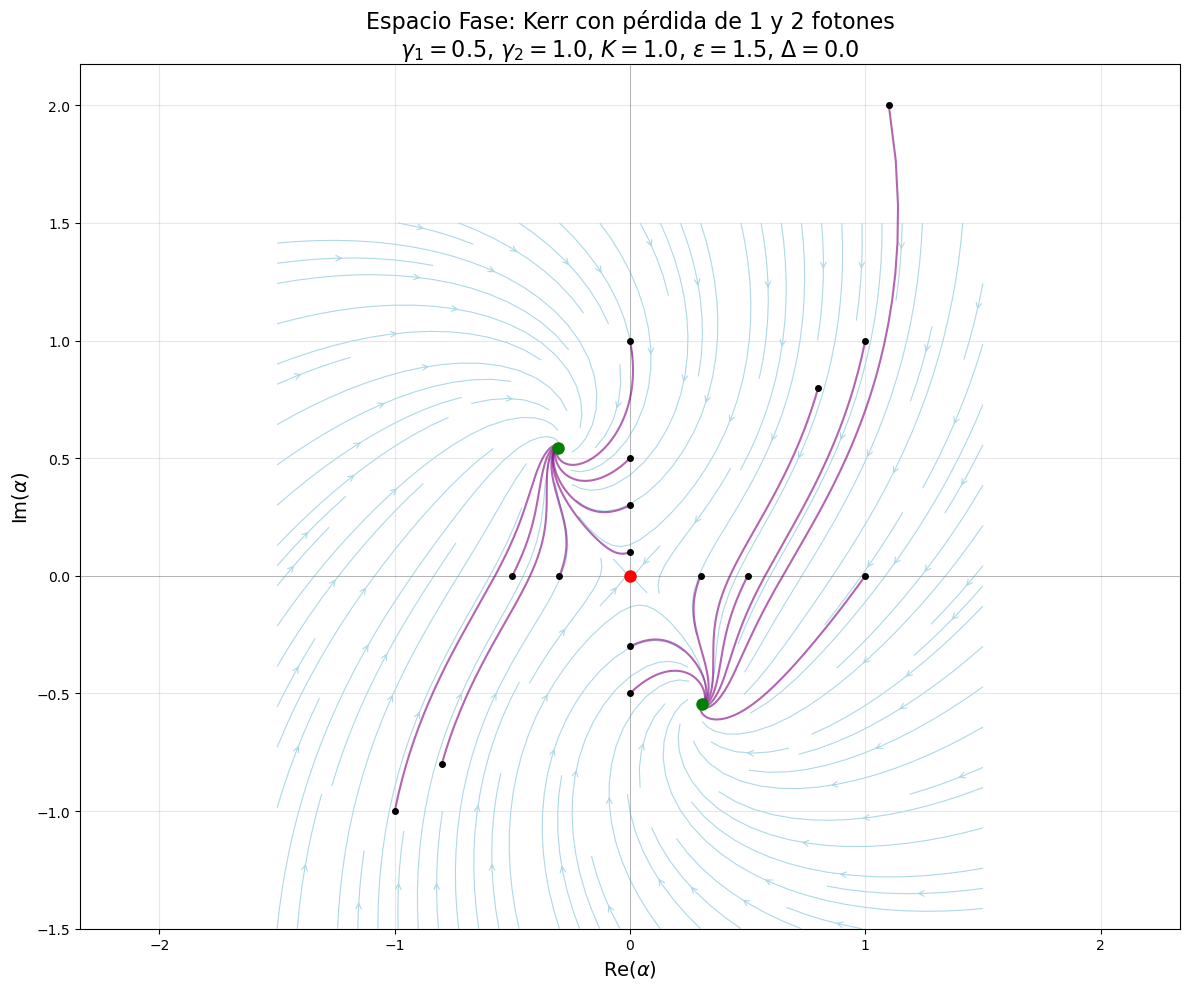

PUNTOS FIJOS - SISTEMA KERR CON PÉRDIDA DE 1 Y 2 FOTONES
γ₁ = 0.5 (pérdida 1 fotón)
γ₂ = 1.0 (pérdida 2 fotones)
K = 1.0, ε = 1.5, Δ = 0.0

Trivial (inestable):
  α = 0.000000+0.000000j
  |α| = 0.000000
  n = |α|² = 0.000000
  θ = 0.000000 rad

No trivial (r=0.6248):
  α = 0.305928-0.544790j
  |α| = 0.624811
  n = |α|² = 0.390388
  θ = -1.059127 rad

No trivial (r=0.6248):
  α = -0.305928+0.544790j
  |α| = 0.624811
  n = |α|² = 0.390388
  θ = 2.082466 rad

ANÁLISIS DE ESTABILIDAD DE PUNTOS FIJOS

No trivial (r=0.6248) en α = 0.3059-0.5448j:
  n = 0.390388
  → Punto fijo no trivial (posiblemente estable o inestable)

No trivial (r=0.6248) en α = -0.3059+0.5448j:
  n = 0.390388
  → Punto fijo no trivial (posiblemente estable o inestable)


In [19]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint


# ============================================
# PARAMETROS DEL SISTEMA
# ============================================

gamma1 = 0.5      # Tasa de pérdida de 1 fotón
gamma2 = 1.0      # Tasa de pérdida de 2 fotones
k = 1.0           # No linealidad Kerr
epsilon = 1.5     # Driving paramétrico
Delta = 0.0       # Detuning


# ============================================
# SISTEMA DE ECUACIONES DE CAMPO MEDIO
# ============================================

def sistema(y, t, gamma1, gamma2, k, epsilon, Delta):
    """
    Ecuación de campo medio para Kerr con pérdida de 1 y 2 fotones:
    
    dα/dt = (iΔ - i k|α|² - γ₁/2 - γ₂|α|²)α - i ε/2 α*
    """
    x, y_im = y
    alpha = x + 1j*y_im
    n = np.abs(alpha)**2

    # Ecuación de campo medio completa
    dalpha_dt = (
        (1j*Delta - 1j*k*n - gamma1/2 - gamma2*n) * alpha
        - 1j*epsilon/2 * np.conj(alpha)
    )

    return [np.real(dalpha_dt), np.imag(dalpha_dt)]


# ============================================
# PUNTOS FIJOS
# ============================================

def puntos_fijos(gamma1, gamma2, k, epsilon, Delta):
    """
    Encuentra los puntos fijos resolviendo el sistema de ecuaciones exactamente.
    
    Para α = x + iy, las ecuaciones de estado estacionario son:
    
    dx/dt = (Δ - k(x²+y²))y - (γ₁/2 + γ₂(x²+y²))x + (ε/2) y = 0
    dy/dt = -(Δ - k(x²+y²))x - (γ₁/2 + γ₂(x²+y²))y - (ε/2) x = 0
    
    O en forma polar α = r e^(iθ):
    
    dr/dt = -(γ₁/2 + γ₂ r²)r - (ε/2) r sin(2θ) = 0
    dθ/dt = Δ - k r² - (ε/2) cos(2θ) = 0
    """
    
    puntos = []
    
    # Punto trivial: α = 0 siempre es solución
    puntos.append((0.0, 0.0, 'Trivial (inestable)'))
    
    # Para puntos no triviales (r > 0)
    # De dr/dt = 0:
    # (γ₁/2 + γ₂ r²)r = -(ε/2) r sin(2θ)
    # Si r > 0: γ₁/2 + γ₂ r² = -(ε/2) sin(2θ)
    # => sin(2θ) = -2(γ₁/2 + γ₂ r²)/ε = -(γ₁ + 2γ₂ r²)/ε
    
    # De dθ/dt = 0:
    # Δ - k r² = (ε/2) cos(2θ)
    # => cos(2θ) = 2(Δ - k r²)/ε
    
    # Usando sin²(2θ) + cos²(2θ) = 1:
    # [(γ₁ + 2γ₂ r²)/ε]² + [2(Δ - k r²)/ε]² = 1
    # (γ₁ + 2γ₂ r²)² + 4(Δ - k r²)² = ε²
    
    # Definimos la función para encontrar r
    def ecuacion_r(r):
        if r < 0:
            return 1e10
        return (gamma1 + 2*gamma2*r**2)**2 + 4*(Delta - k*r**2)**2 - epsilon**2
    
    # Buscamos raíces en el rango [0, r_max]
    r_max = np.sqrt(max(0, (gamma1 + np.sqrt(epsilon**2))/ (2*gamma2))) if gamma2 > 0 else 2.0
    r_max = min(r_max, 5.0)  # Límite superior
    
    r_vals = []
    r_range = np.linspace(0, r_max, 2000)
    
    for i in range(len(r_range)-1):
        r1 = r_range[i]
        r2 = r_range[i+1]
        
        f1 = ecuacion_r(r1)
        f2 = ecuacion_r(r2)
        
        if f1 * f2 < 0:
            # Bisección para encontrar la raíz con precisión
            r_low, r_high = r1, r2
            for _ in range(50):
                r_mid = (r_low + r_high) / 2
                f_mid = ecuacion_r(r_mid)
                if f_mid * ecuacion_r(r_low) < 0:
                    r_high = r_mid
                else:
                    r_low = r_mid
            
            r_root = (r_low + r_high) / 2
            if r_root > 1e-8:
                # Verificar que no sea duplicado
                is_duplicate = False
                for existing_r in r_vals:
                    if abs(r_root - existing_r) < 1e-6:
                        is_duplicate = True
                        break
                if not is_duplicate:
                    r_vals.append(r_root)
    
    # Para cada r, encontramos θ
    for r in r_vals:
        r2 = r**2
        
        # Calcular sin(2θ) y cos(2θ)
        sin_2theta = -(gamma1 + 2*gamma2*r2) / epsilon
        cos_2theta = 2*(Delta - k*r2) / epsilon
        
        # Normalizar (por si hay errores numéricos)
        norm = np.sqrt(sin_2theta**2 + cos_2theta**2)
        if norm > 0:
            sin_2theta /= norm
            cos_2theta /= norm
        
        # Asegurar que están en el rango [-1, 1]
        sin_2theta = np.clip(sin_2theta, -1, 1)
        cos_2theta = np.clip(cos_2theta, -1, 1)
        
        # Calcular θ
        theta = 0.5 * np.arctan2(sin_2theta, cos_2theta)
        
        # Hay dos soluciones: θ y θ + π
        for theta_sol in [theta, theta + np.pi]:
            alpha = r * np.exp(1j * theta_sol)
            puntos.append((np.real(alpha), np.imag(alpha), f'No trivial (r={r:.4f})'))
    
    return puntos


# ============================================
# CAMPO VECTORIAL
# ============================================

def campo_vectorial(X, Y, gamma1, gamma2, k, epsilon, Delta):
    U = np.zeros_like(X)
    V = np.zeros_like(Y)

    for i in range(X.shape[0]):
        for j in range(X.shape[1]):
            alpha = X[i, j] + 1j*Y[i, j]
            n = np.abs(alpha)**2

            dalpha_dt = (
                (1j*Delta - 1j*k*n - gamma1/2 - gamma2*n) * alpha
                - 1j*epsilon/2 * np.conj(alpha)
            )

            U[i, j] = np.real(dalpha_dt)
            V[i, j] = np.imag(dalpha_dt)

    return U, V


# ============================================
# TRAYECTORIA
# ============================================

def trayectoria(alpha0, gamma1, gamma2, k, epsilon, Delta,
                t_max=20, n_points=1000):
    t = np.linspace(0, t_max, n_points)
    X_0 = np.real(alpha0)
    Y_0 = np.imag(alpha0)

    sol = odeint(
        sistema,
        [X_0, Y_0],
        t,
        args=(gamma1, gamma2, k, epsilon, Delta)
    )

    trayectoria_complex = sol[:, 0] + 1j*sol[:, 1]
    return trayectoria_complex, t



# ============================================
# CONFIGURACION DE LA GRAFICA
# ============================================

plt.figure(figsize=(12, 10))

lim = 1.5
x = np.linspace(-lim, lim, 35)
y = np.linspace(-lim, lim, 35)
X, Y = np.meshgrid(x, y)


# ============================================
# CAMPO VECTORIAL (Streamplot)
# ============================================

U, V = campo_vectorial(X, Y, gamma1, gamma2, k, epsilon, Delta)

plt.streamplot(
    X, Y,
    U, V,
    color='lightblue',
    linewidth=0.8,
    density=1.2,
    arrowstyle='->',
    arrowsize=1.0
)


# ============================================
# PUNTOS FIJOS
# ============================================

puntos = puntos_fijos(gamma1, gamma2, k, epsilon, Delta)

# Para evitar duplicados
puntos_unicos = []
for p in puntos:
    if p not in puntos_unicos:
        puntos_unicos.append(p)

for xp, yp, label in puntos_unicos:
    if 'Trivial' in label:
        plt.plot(xp, yp, 'ro', markersize=8, label=label, zorder=5)
    else:
        plt.plot(xp, yp, 'go', markersize=8, label=label, zorder=5)


# ============================================
# TRAYECTORIAS
# ============================================

ini_con = [
    1.1 + 2.0j, 0.0 + 0.1j,
    0.3 + 0.0j, 0.0 + 0.3j,
    -0.3 + 0.0j, 0.0 - 0.3j,
    0.5 + 0.0j, 0.0 + 0.5j,
    -0.5 + 0.0j, 0.0 - 0.5j,
    0.8 + 0.8j, -0.8 - 0.8j,
    1.0 + 0.0j, 0.0 + 1.0j,
    1.0 + 1.0j, -1.0 - 1.0j
]

for alpha0 in ini_con:
    tray, t = trayectoria(
        alpha0,
        gamma1, gamma2, k, epsilon, Delta,
        t_max=30,
        n_points=2000
    )

    plt.plot(
        np.real(tray),
        np.imag(tray),
        color='purple',
        alpha=0.6,
        linewidth=1.5
    )

    # Punto inicial
    plt.plot(
        np.real(alpha0),
        np.imag(alpha0),
        'k.',
        markersize=8
    )




# ============================================
# EJES
# ============================================

plt.axhline(0, color='black', linewidth=0.5, alpha=0.3)
plt.axvline(0, color='black', linewidth=0.5, alpha=0.3)


# ============================================
# ETIQUETAS
# ============================================

plt.xlabel(r'Re($\alpha$)', fontsize=14)
plt.ylabel(r'Im($\alpha$)', fontsize=14)

plt.title(
    f'Espacio Fase: Kerr con pérdida de 1 y 2 fotones\n'
    f'$\\gamma_1={gamma1}$, $\\gamma_2={gamma2}$, $K={k}$, '
    f'$\\epsilon={epsilon}$, $\\Delta={Delta}$',
    fontsize=16
)

plt.grid(True, alpha=0.3)
plt.axis('equal')

plt.tight_layout()

# Guardar figura
plt.savefig('1_2photon/PhaseSpace_Kerr_1y2fotones.pdf', dpi=300, bbox_inches='tight')
plt.show()


# ============================================
# INFORMACION DE LOS PUNTOS FIJOS
# ============================================

print("="*70)
print("PUNTOS FIJOS - SISTEMA KERR CON PÉRDIDA DE 1 Y 2 FOTONES")
print("="*70)
print(f"γ₁ = {gamma1} (pérdida 1 fotón)")
print(f"γ₂ = {gamma2} (pérdida 2 fotones)")
print(f"K = {k}, ε = {epsilon}, Δ = {Delta}")
print("="*70)

for xp, yp, label in puntos_unicos:
    alpha = xp + 1j*yp
    r = np.abs(alpha)
    n = r**2
    theta = np.angle(alpha)
    
    print(f"\n{label}:")
    print(f"  α = {alpha:.6f}")
    print(f"  |α| = {r:.6f}")
    print(f"  n = |α|² = {n:.6f}")
    print(f"  θ = {theta:.6f} rad")


# ============================================
# ANÁLISIS DE ESTABILIDAD (opcional)
# ============================================

print("\n" + "="*70)
print("ANÁLISIS DE ESTABILIDAD DE PUNTOS FIJOS")
print("="*70)

for xp, yp, label in puntos_unicos:
    if np.abs(xp) < 1e-10 and np.abs(yp) < 1e-10:
        continue
    
    alpha = xp + 1j*yp
    n = np.abs(alpha)**2
    
    # Jacobiano aproximado (para análisis cualitativo)
    # J = [ -γ₁/2 - 3γ₂ n - 2k Im(α)²,  -γ₂ x y - (k/2)(2n + ...) ]
    # Esto es simplificado
    
    print(f"\n{label} en α = {alpha:.4f}:")
    print(f"  n = {n:.6f}")
    
    # Criterio simple: si n > 0, es un punto fijo no trivial
    if n > 0:
        print("  → Punto fijo no trivial (posiblemente estable o inestable)")
    else:
        print("  → Punto fijo trivial (α = 0)")


